In [5]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    roc_auc_score,
    classification_report
)

df = pd.read_csv("../data/higgs_sample.csv")

X = df.drop(columns="target")
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training:", X_train.shape)
print("Testing:", X_test.shape)

Training: (160000, 28)
Testing: (40000, 28)


In [6]:
model = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(max_iter=1000))
])

model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

Accuracy: 0.640675
Precision: 0.6386337543053962
Recall: 0.7369292642536077
ROC-AUC: 0.682837671398092


In [7]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print(cm)


[[10052  8813]
 [ 5560 15575]]


Saved to: C:\Users\yunac\OneDrive\Documents\GitHub\higgsmlproject\figures\logistic_regression_confusion_matrix.png


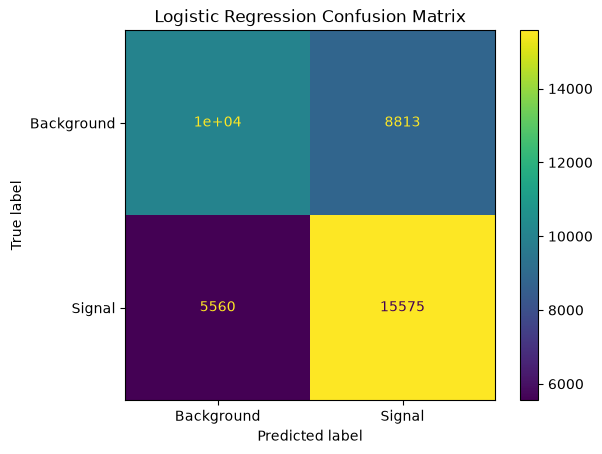

Saved to: C:\Users\yunac\OneDrive\Documents\GitHub\higgsmlproject\figures\logistic_regression_roc.png


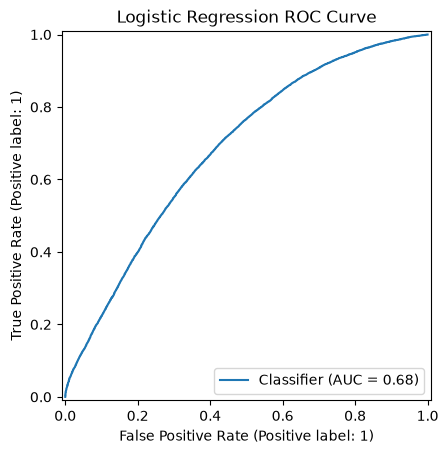

In [8]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay

# Confusion matrix
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=["Background", "Signal"]
)

plt.title("Logistic Regression Confusion Matrix")
from pathlib import Path

figures_dir = Path(r"C:\Users\yunac\OneDrive\Documents\GitHub\higgsmlproject\figures")
figures_dir.mkdir(parents=True, exist_ok=True)

plt.savefig(
    figures_dir / "logistic_regression_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

print("Saved to:", figures_dir / "logistic_regression_confusion_matrix.png")
plt.show()


# ROC curve
RocCurveDisplay.from_predictions(
    y_test,
    y_prob
)

plt.title("Logistic Regression ROC Curve")
from pathlib import Path

figures_dir = Path(r"C:\Users\yunac\OneDrive\Documents\GitHub\higgsmlproject\figures")
figures_dir.mkdir(parents=True, exist_ok=True)

plt.savefig(
    figures_dir / "logistic_regression_roc.png",
    dpi=300,
    bbox_inches="tight"
)

print("Saved to:", figures_dir / "logistic_regression_roc.png")
plt.show()